In [17]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import chatterjeexi

from scipy.stats import PermutationMethod,permutation_test,false_discovery_control

# Analysis


ADH: 2
sp: -0.9973303670745272
xi: 0.8832035595105673
ADH: 5
sp: -0.6320355951056729
xi: 0.8164627363737487
ADH: 8
sp: 0.06607341490545049
xi: 0.8097886540600667


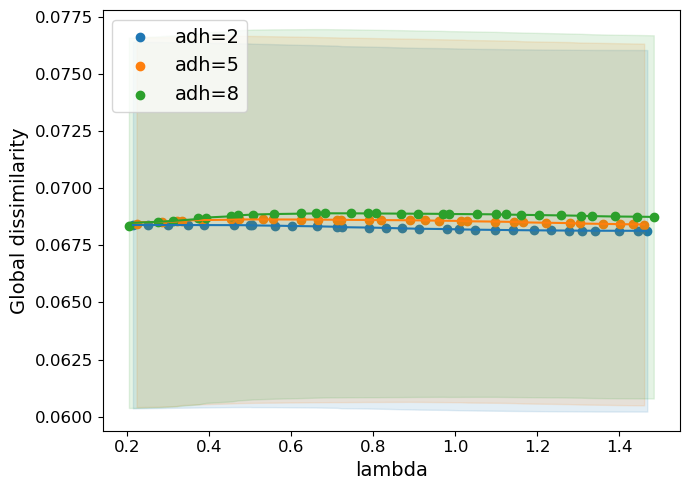

In [38]:
# df_name="run_metrics/run_metrics_unity_Drep5_cham.csv"
df = pd.read_csv("run_metrics/endstate/run_metrics_unity_Drep5_cham.csv")

#df=df[df["dif"] >=0.5]
# df=df[df["adh"] <8]
window = 5   
xcol = "dif"
ycol = "global_d"

fig, ax = plt.subplots(figsize=(7, 5))
stat_labels = []

#ana for separte adh levels
for adh, g in df.dropna(subset=[xcol, ycol]).sort_values(xcol).groupby("adh"):
    x = g[xcol]
    y = g[ycol]
    sd = g["global_d_sd"]/np.sqrt(12)
    
    #coefficients
    s,ps=spearmanr(x,y)
    xi_res = chatterjeexi( x, y, y_continuous=True,  method="asymptotic")

    xi = xi_res.statistic
    p = xi_res.pvalue
    print("ADH:", adh)
    print("sp:", s)
    print("xi:", xi)
   # rolling mean line through points
    smooth = y.rolling(window=window, center=True,min_periods=1).mean()
    line, = ax.plot( x,smooth)
    ax.scatter( x, y, label=f"adh={adh}", color=line.get_color())
    ax.fill_between( x, smooth - sd, smooth + sd,color=line.get_color(),alpha=0.123)
    
    #stats save
    stat_labels.append({
        "adh": adh,
        "xi": xi,
        "sp": s,
        "color": line.get_color()
    })

plt.xlabel("lambda", fontsize=14)
plt.ylabel("Global dissimilarity", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.tick_params(axis="both", labelsize=12)

# plt.ylim((0.09061684723859698, 0.22018470987065372))
# plt.title(f"{df_name}")
plt.tight_layout()
#plt.savefig("test.svg", format="svg")
plt.show()

In [31]:
df = pd.read_csv("run_metrics_nob/run_metrics_unity_adh5_cham.csv")
df

,rep,dif,adh,metric_d,metric_d_sd,metric_s,metric_s_sd,global_d,global_d_sd
0,5.0,0.841111,5,0.127859,0.032637,0.858283,0.012042,0.096042,0.030332
1,5.0,1.032393,5,0.131129,0.030042,0.854850,0.011482,0.096158,0.030155
2,5.0,0.475385,5,0.115911,0.032967,0.854467,0.009861,0.095760,0.031012
3,5.0,1.469371,5,0.134410,0.023422,0.858283,0.011035,0.096375,0.029853
4,5.0,0.530970,5,0.118431,0.033485,0.854600,0.009664,0.095813,0.030849
5,5.0,1.310632,5,0.134022,0.025693,0.856167,0.010998,0.096290,0.029956
6,5.0,1.194380,5,0.132741,0.027522,0.855850,0.011492,0.096253,0.030040
7,5.0,0.218995,5,0.100684,0.028087,0.848917,0.017765,0.095509,0.031816
8,5.0,0.248179,5,0.102377,0.028715,0.852183,0.018639,0.095545,0.031755
9,5.0,1.137486,5,0.132451,0.028390,0.855300,0.011582,0.096215,0.030078


In [6]:
# 3d cube view
# 
# import plotly.graph_objects as go
# 
# fig = go.Figure(data=[go.Scatter3d(
#     x=df["rep"],
#     y=df["dif"],
#     z=df["adh"],
#     mode='markers',
#     marker=dict(
#         size=5,
#         color=df["metric_d"],      # your metric
#         colorscale='Viridis',
#         colorbar=dict(title='Shape dissimilarity')
#     )
# )])
# 
# fig.update_layout(
#     scene=dict(
#         xaxis_title='rep',
#         yaxis_title='dif',
#         zaxis_title='adh'
#     )
# )
# 
# fig.show()

# Analysis w pval

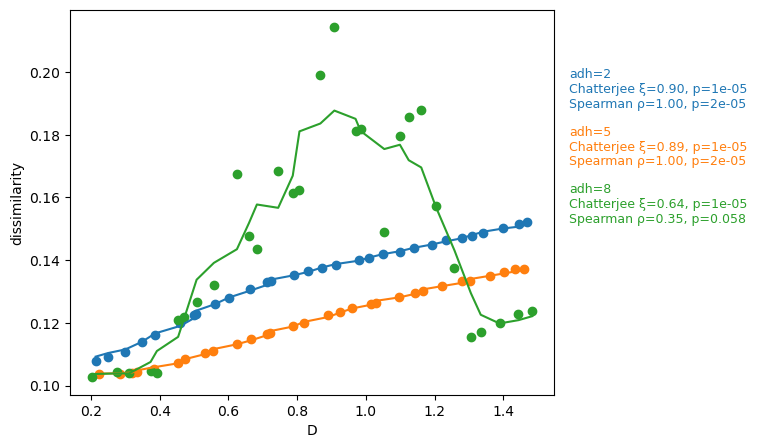

In [37]:
df = pd.read_csv("run_metrics/ver2b/run_metrics_ver2b_Drep5_cham.csv")
# df = df[df["dif"] >= 0.2]
#df = df[df["dif"] <= 1.1]

window = 5
#for resampling permuations
n_perm = 100000
rng = np.random.default_rng(0)

xcol = "dif"
ycol = "metric_d"


fig, ax = plt.subplots(figsize=(8, 5))
stat_labels = []

# extra func only for spearman as it does not support perm. directly
def spearman_stat(x, y):
    return spearmanr(x, y).statistic

# for sep. adh levels
for adh, g in df.dropna(subset=[xcol, ycol]).sort_values(xcol).groupby("adh"):

    x = g[xcol]
    y = g[ycol]
    
    #stats + permuted pval
    xi,p_xi = chatterjeexi(x, y, y_continuous=True, method=PermutationMethod(n_resamples=n_perm, rng=rng))
    
    res = permutation_test((x, y), spearman_stat, permutation_type="pairings",alternative="two-sided",n_resamples=n_perm, rng=rng)
    p_sp=res.pvalue
    sp,_ = spearmanr(x, y)
    
   # rolling mean line
   
    smooth = y.rolling(  window=window, center=True,min_periods=1).mean()
    line, = ax.plot( x,smooth)
    ax.scatter(x, y, color=line.get_color(), label=f"adh={adh}")

    stat_labels.append((adh, xi, p_xi, sp, p_sp, line.get_color()))


ax.set_xlabel("D")
ax.set_ylabel("dissimilarity")
fig.subplots_adjust(right=0.73)

#multiple test correction (?) - idk if i need even
# xi_p_adj = false_discovery_control([s[2] for s in stat_labels])
# sp_p_adj = false_discovery_control([s[4] for s in stat_labels])

#text
for i, (adh, xi, p_xi, sp, p_sp, color) in enumerate(stat_labels):
    ax.text(
        1.03,
        0.85 - i * 0.15,
        f"adh={adh}\n"
        f"Chatterjee ξ={xi:.2f}, p={p_xi:.2g}\n"
        f"Spearman ρ={sp:.2f}, p={p_sp:.2g}",
        transform=ax.transAxes,
        color=color,
        fontsize=9,
        va="top",
        ha="left",
        clip_on=False
    )

plt.show()

# Automated plots

In [16]:
################################
# Settings
################################
input_dir = Path("run_metrics/ver2")
output_dir = input_dir / "corr_sd_run_metric_plots"
output_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(input_dir.glob("run_metrics*.csv"))

xcol = "dif"
ycols = ["metric_d", "global_d"]
ylabels = {
    "metric_d": "Local dissimilarity",
    "global_d": "Global dissimilarity"
}

window = 5
n_perm = 100000
rng = np.random.default_rng(0)


################################
#Data + ylims for plots having same axis
################################
dfs = {file: pd.read_csv(file) for file in csv_files}

common_ylims = {}

for ycol in ycols: #for axis (same raneg + buffer)
    values = pd.concat([df[ycol] for df in dfs.values()]).dropna()
    padding = (values.max() - values.min()) * 0.05
    common_ylims[ycol] = (values.min() - padding, values.max() + padding)


################################
# for permutation (only sp)
################################
def spearman_stat(x, y):
    return spearmanr(x, y).statistic


################################
#plots and statistics
################################
all_stats = []

for file, df in dfs.items():


    print(file)
    # df = df[df["dif"] >= 0.2]
    # df = df[df["dif"] <= 1.1]

    for ycol in ycols:

        fig, ax = plt.subplots(figsize=(7, 5))

        for adh, g in df.dropna(subset=[xcol, ycol, "adh"]).sort_values(xcol).groupby("adh"):

            x = g[xcol]
            y = g[ycol]
            if ycol == "metric_d":
                sd = g["metric_d_sd"]/np.sqrt(18)
            elif ycol == "global_d":
                sd = g["global_d_sd"]/np.sqrt(30)
            statistics
            xi, p_xi = chatterjeexi(x, y, y_continuous=True, method=PermutationMethod(n_resamples=n_perm, rng=rng))

            res = permutation_test((x, y), spearman_stat, permutation_type="pairings", alternative="two-sided", n_resamples=n_perm, rng=rng)
            p_sp = res.pvalue
            sp, _ = spearmanr(x, y)

            # rolling mean
            smooth = y.rolling(window=window, center=True, min_periods=1).mean()
            line, = ax.plot(x, smooth)
            ax.scatter(x, y, color=line.get_color(), label=f"adh={adh}")
            ax.fill_between( x, smooth - sd, smooth + sd,color=line.get_color(),alpha=0.123)
            row = {
                "file": file.name,
                "metric": ycol,
                "adh": adh,
                "n": len(g),
                "spearman_rho": sp,
                "spearman_p": p_sp,
                "chatterjee_xi": xi,
                "chatterjee_p": p_xi
            }

            
            all_stats.append(row)

        ax.set_xlabel("D", fontsize=14)
        ax.set_ylabel(ylabels[ycol], fontsize=14)
        ax.set_ylim(common_ylims[ycol])
        ax.legend(loc="upper left", fontsize=14)
        ax.tick_params(axis="both", labelsize=12)
        plt.tight_layout()
        plt.savefig(output_dir / f"{file.stem}_{ycol}lam.png", dpi=300)
        plt.close()

    

################################
#all statistics
################################
pd.DataFrame(all_stats).to_csv(output_dir / "all_run_metrics_correlations.csv", index=False)


ver2\run_metrics_ver2_Drep.csv
ver2\run_metrics_ver2_Drep5_cham.csv
ver2\run_metrics_ver2_Drep_cham.csv


In [39]:
#magnitudes

input_dir = Path("run_metrics_nob")
csv_files = sorted(input_dir.glob("run_metrics*.csv"))

xcol = "dif"
ycols = ["metric_d", "global_d"]

################################
#Data 
################################
dfs = {file: pd.read_csv(file) for file in csv_files}


for file, df in dfs.items():

    file_stats = []

    # df = df[df["dif"] >= 0.5]
    # df = df[df["dif"] <= 1.1]
    print(file)
    for ycol in ycols:
        
        if ycol == "metric_d":
            #so that local +/- similar to globa; cause of squard error mean 
            metric_d_rms = np.sqrt(df[ycol] / 6)          
            print(ycol, " has ",(metric_d_rms.max() - metric_d_rms.min()) / metric_d_rms.min() )
            continue
            
        print(ycol, " has ",(df[ycol].max() - df[ycol].min()) / df[ycol].min() )
        

run_metrics_nob\run_metrics_unity_adh5_cham.csv
metric_d  has  0.15571547579644818
global_d  has  0.009198297117708533
run_metrics_nob\run_metrics_unity_Drep5_cham.csv
metric_d  has  0.2938283151567639
global_d  has  0.015448563414514742
run_metrics_nob\run_metrics_ver2b_adh5_cham.csv
metric_d  has  0.18289012665834709
global_d  has  0.03014530840540591
run_metrics_nob\run_metrics_ver2b_Drep5_cham.csv
metric_d  has  0.3310639819734893
global_d  has  0.0947510967973807
